In [1]:
import pandas as pd
import numpy as np
import emoji
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD SPAMID-PAIR (YOUR TRAINING DATA)
# ============================================
print("Loading SPAMID-PAIR dataset...")
df_train = pd.read_csv('/kaggle/input/datasets/goyalsaloni/emoji-tweets/SPAMID-PAIR/Analyzed/dataset-csv.csv', 
                       sep=';', on_bad_lines='skip', encoding='utf-8')
df_train = df_train.dropna(axis=1, how='all')
print(f"Loaded {len(df_train)} samples")

# ============================================
# STEP 2: EXTRACT EMOJIS FROM COMMENTS
# ============================================
def extract_emojis(text):
    """Extract all emojis from text"""
    if pd.isna(text):
        return []
    return [c for c in str(text) if c in emoji.EMOJI_DATA]

print("\nExtracting emojis from comments...")
df_train['emojis'] = df_train['comment'].apply(extract_emojis)
df_train['emoji_count'] = df_train['emojis'].apply(len)

# Keep only samples WITH emojis for training
df_train_with_emojis = df_train[df_train['emoji_count'] > 0].copy()
print(f"Samples with emojis for training: {len(df_train_with_emojis)}")

# ============================================
# STEP 3: SELECT TOP EMOJIS TO PREDICT
# ============================================
all_emojis = []
for emojis in df_train_with_emojis['emojis']:
    all_emojis.extend(emojis)

emoji_freq = Counter(all_emojis)
TOP_N_EMOJIS = 30  # You can adjust this (20-50 is good)
top_emojis = [e for e, _ in emoji_freq.most_common(TOP_N_EMOJIS)]

print(f"\nTop {TOP_N_EMOJIS} emojis to predict:")
for i, e in enumerate(top_emojis[:10]):
    try:
        name = emoji.demojize(e)
    except:
        name = "unknown"
    print(f"{i+1}. {e} - {name}")

# ============================================
# STEP 4: CREATE MULTI-HOT LABELS
# ============================================
def create_multi_hot(emojis_list):
    """Convert list of emojis to multi-hot vector"""
    return [1 if e in emojis_list else 0 for e in top_emojis]

df_train_with_emojis['label_vector'] = df_train_with_emojis['emojis'].apply(create_multi_hot)

# Clean text - REMOVE emojis from input (we want to predict them from plain text)
df_train_with_emojis['clean_text'] = df_train_with_emojis['comment'].apply(
    lambda x: emoji.replace_emoji(str(x), replace='').strip()
)

# Remove samples with empty text after cleaning
df_train_with_emojis = df_train_with_emojis[df_train_with_emojis['clean_text'].str.len() > 0].copy()
print(f"\nFinal training samples: {len(df_train_with_emojis)}")

# ============================================
# STEP 5: TRAIN THE MODEL (THIS IS THE KEY PART!)
# ============================================
print("\nTraining emoji prediction model...")

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X = vectorizer.fit_transform(df_train_with_emojis['clean_text'])
y = np.array(df_train_with_emojis['label_vector'].tolist())

print(f"Feature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train multi-label classifier (OneVsRest with Logistic Regression)
model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'))
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f"Training accuracy: {train_score:.4f}")
print(f"Validation accuracy: {val_score:.4f}")

# ============================================
# STEP 6: NOW PREDICT FOR MVSA TEXTS
# ============================================
print("\n" + "="*50)
print("PREDICTING EMOJIS FOR MVSA TEXTS")
print("="*50)

# Your MVSA texts (replace with your actual MVSA data)
mvsa_texts = [
    "I really enjoyed the movie, it was fantastic",
    "This product is terrible, I hate it",
    "Just another ordinary day, nothing special",
    "Wow! This is absolutely amazing news!",
    "I'm so angry right now, can't believe this happened",
    "Feeling blessed and grateful for everything",
    "This is the worst experience ever",
    "Okay, I guess it's fine",
]

def predict_emojis(texts, model, vectorizer, top_emojis, threshold=0.3):
    """Predict emojis for a list of texts"""
    # Vectorize the texts
    X_new = vectorizer.transform(texts)
    
    # Get prediction probabilities
    probs = model.predict_proba(X_new)
    
    results = []
    for i, text in enumerate(texts):
        # Get emojis with probability > threshold
        predicted_indices = np.where(probs[i] > threshold)[0]
        predicted_emojis = [top_emojis[idx] for idx in predicted_indices]
        
        # Sort by probability
        prob_dict = {top_emojis[idx]: probs[i][idx] for idx in predicted_indices}
        prob_dict = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True))
        
        results.append({
            'text': text,
            'predicted_emojis': predicted_emojis,
            'emoji_string': ''.join(predicted_emojis),
            'probabilities': prob_dict
        })
    
    return pd.DataFrame(results)

# Make predictions
mvsa_predictions = predict_emojis(mvsa_texts, model, vectorizer, top_emojis)

# Show results
print("\n=== PREDICTED EMOJIS FOR MVSA TEXTS ===")
for idx, row in mvsa_predictions.iterrows():
    print(f"\nText: {row['text']}")
    print(f"Predicted emojis: {row['emoji_string']} ({row['predicted_emojis']})")
    if row['probabilities']:
        top_3 = list(row['probabilities'].items())[:3]
        print(f"Top predictions: {[f'{e}: {p:.2f}' for e, p in top_3]}")

# ============================================
# STEP 7: CREATE AUGMENTED MVSA DATASET
# ============================================
def create_augmented_mvsa(original_texts, predictions_df):
    """Create MVSA dataset with predicted emojis"""
    augmented = []
    
    for i, text in enumerate(original_texts):
        pred_row = predictions_df.iloc[i]
        
        # Version with emojis appended
        text_with_emojis = f"{text} {pred_row['emoji_string']}"
        
        # Version with emojis converted to descriptions (for CLIP)
        text_with_descriptions = emoji.demojize(text_with_emojis)
        
        augmented.append({
            'original_text': text,
            'predicted_emojis': pred_row['emoji_string'],
            'text_with_emojis': text_with_emojis,
            'text_for_clip': text_with_descriptions,
            'has_prediction': len(pred_row['predicted_emojis']) > 0,
            'num_emojis': len(pred_row['predicted_emojis'])
        })
    
    return pd.DataFrame(augmented)

# Create augmented dataset
mvsa_augmented = create_augmented_mvsa(mvsa_texts, mvsa_predictions)

print("\n" + "="*50)
print("AUGMENTED MVSA DATASET")
print("="*50)
print(mvsa_augmented[['original_text', 'predicted_emojis', 'text_for_clip']].head(10))

# ============================================
# STEP 8: SAVE EVERYTHING
# ============================================
print("\nSaving model and data...")

# Save the model and vectorizer
joblib.dump(model, '/kaggle/working/emoji_predictor_model.pkl')
joblib.dump(vectorizer, '/kaggle/working/emoji_vectorizer.pkl')
joblib.dump(top_emojis, '/kaggle/working/top_emojis.pkl')

# Save augmented MVSA
mvsa_augmented.to_csv('/kaggle/working/mvsa_with_predicted_emojis.csv', index=False)

print("\n✅ All files saved to /kaggle/working/")
print("Files created:")
print("  - emoji_predictor_model.pkl (the trained model)")
print("  - emoji_vectorizer.pkl (TF-IDF vectorizer)")
print("  - top_emojis.pkl (list of emojis)")
print("  - mvsa_with_predicted_emojis.csv (augmented dataset)")

# ============================================
# STEP 9: QUICK ANALYSIS
# ============================================
print("\n" + "="*50)
print("QUICK ANALYSIS OF PREDICTIONS")
print("="*50)

# What kinds of emojis were predicted?
all_predicted = []
for emojis in mvsa_augmented['predicted_emojis']:
    all_predicted.extend(list(emojis))

predicted_freq = Counter(all_predicted)
print("\nMost predicted emojis:")
for e, count in predicted_freq.most_common(5):
    try:
        name = emoji.demojize(e)
    except:
        name = "unknown"
    print(f"  {e}: {count} times ({name})")

print(f"\nAverage emojis per text: {mvsa_augmented['num_emojis'].mean():.2f}")
print(f"Texts with predictions: {mvsa_augmented['has_prediction'].sum()}/{len(mvsa_augmented)}")

Loading SPAMID-PAIR dataset...
Loaded 72999 samples

Extracting emojis from comments...
Samples with emojis for training: 50142

Top 30 emojis to predict:
1. ❤ - :red_heart:
2. 😍 - :smiling_face_with_heart-eyes:
3. 🔥 - :fire:
4. 👏 - :clapping_hands:
5. 😂 - :face_with_tears_of_joy:
6. 🙌 - :raising_hands:
7. 👍 - :thumbs_up:
8. 😢 - :crying_face:
9. 😘 - :face_blowing_a_kiss:
10. 🙏 - :folded_hands:

Final training samples: 25999

Training emoji prediction model...
Feature matrix shape: (25999, 5000)
Target matrix shape: (25999, 30)
Training accuracy: 0.0584
Validation accuracy: 0.0350

PREDICTING EMOJIS FOR MVSA TEXTS

=== PREDICTED EMOJIS FOR MVSA TEXTS ===

Text: I really enjoyed the movie, it was fantastic
Predicted emojis: ❤🔥👏💜♥💖🥰🤩🏻 (['❤', '🔥', '👏', '💜', '♥', '💖', '🥰', '🤩', '🏻'])
Top predictions: ['🤩: 0.73', '💜: 0.58', '🏻: 0.57']

Text: This product is terrible, I hate it
Predicted emojis: ❤😍🔥👏😂😘😮💖😊 (['❤', '😍', '🔥', '👏', '😂', '😘', '😮', '💖', '😊'])
Top predictions: ['🔥: 0.60', '😘: 0.60', 

=== EMOJI DISTRIBUTION IN SPAMID-PAIR ===
Average emojis per post: 2.78
Median emojis per post: 2.00
Mode: 1
Max emojis: 358
95th percentile: 7.0

Distribution:
emoji_count
1     10432
2      6049
3      4160
4      2156
5      1132
6       737
7       424
8       240
9       164
10      108
Name: count, dtype: int64


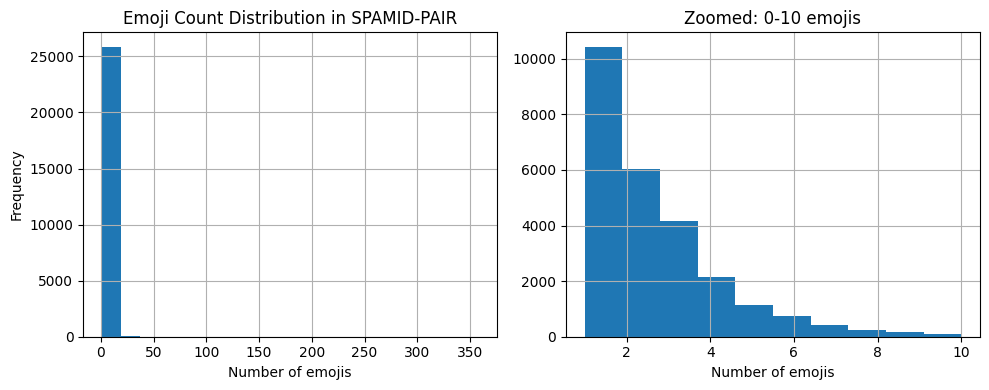

In [2]:
# Add this to see the distribution in your SPAMID-PAIR data
import matplotlib.pyplot as plt

# From your SPAMID-PAIR data
emoji_counts = df_train_with_emojis['emoji_count']
print("=== EMOJI DISTRIBUTION IN SPAMID-PAIR ===")
print(f"Average emojis per post: {emoji_counts.mean():.2f}")
print(f"Median emojis per post: {emoji_counts.median():.2f}")
print(f"Mode: {emoji_counts.mode().values[0]}")
print(f"Max emojis: {emoji_counts.max()}")
print(f"95th percentile: {emoji_counts.quantile(0.95)}")

# Distribution
print("\nDistribution:")
print(emoji_counts.value_counts().sort_index().head(10))

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
emoji_counts.hist(bins=20)
plt.title('Emoji Count Distribution in SPAMID-PAIR')
plt.xlabel('Number of emojis')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
emoji_counts[emoji_counts <= 10].hist(bins=10)  # Zoom in on 0-10
plt.title('Zoomed: 0-10 emojis')
plt.xlabel('Number of emojis')
plt.tight_layout()
plt.show()

In [3]:
# ============================================
# COMPLETE CODE: Predict Top 1 or Top 2 Emojis for MVSA
# ============================================

import pandas as pd
import numpy as np
import emoji
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EMOJI PREDICTION MODEL FOR MVSA DATASET")
print("="*60)

# ============================================
# STEP 1: LOAD SPAMID-PAIR (TRAINING DATA)
# ============================================
print("\n📥 Step 1: Loading SPAMID-PAIR dataset...")
df_train = pd.read_csv('/kaggle/input/datasets/goyalsaloni/emoji-tweets/SPAMID-PAIR/Analyzed/dataset-csv.csv', 
                       sep=';', on_bad_lines='skip', encoding='utf-8')
df_train = df_train.dropna(axis=1, how='all')
print(f"   ✅ Loaded {len(df_train)} samples")

# ============================================
# STEP 2: EXTRACT EMOJIS FROM COMMENTS
# ============================================
print("\n🔍 Step 2: Extracting emojis from comments...")

def extract_emojis(text):
    """Extract all emojis from text"""
    if pd.isna(text):
        return []
    return [c for c in str(text) if c in emoji.EMOJI_DATA]

df_train['emojis'] = df_train['comment'].apply(extract_emojis)
df_train['emoji_count'] = df_train['emojis'].apply(len)

# Keep only samples WITH emojis for training
df_train_with_emojis = df_train[df_train['emoji_count'] > 0].copy()
print(f"   ✅ Samples with emojis for training: {len(df_train_with_emojis)}")

# ============================================
# STEP 3: ANALYZE EMOJI DISTRIBUTION
# ============================================
print("\n📊 Step 3: Analyzing emoji distribution...")

all_emojis = []
for emojis in df_train_with_emojis['emojis']:
    all_emojis.extend(emojis)

emoji_freq = Counter(all_emojis)
TOP_N_EMOJIS = 30  # Predict top 30 most common emojis
top_emojis = [e for e, _ in emoji_freq.most_common(TOP_N_EMOJIS)]

print(f"   📊 Top {TOP_N_EMOJIS} emojis to predict:")
for i, e in enumerate(top_emojis[:5]):
    try:
        name = emoji.demojize(e)
    except:
        name = "unknown"
    print(f"      {i+1}. {e} - {name}")
print("      ...")

# Distribution stats
print(f"\n   📈 Emoji statistics from training data:")
print(f"      • Average emojis per post: {df_train_with_emojis['emoji_count'].mean():.2f}")
print(f"      • Median emojis per post: {df_train_with_emojis['emoji_count'].median():.0f}")
print(f"      • Mode (most common): {df_train_with_emojis['emoji_count'].mode().values[0]} emoji(s)")
print(f"      • 95th percentile: {df_train_with_emojis['emoji_count'].quantile(0.95):.0f} emojis")

# ============================================
# STEP 4: CREATE MULTI-HOT LABELS
# ============================================
print("\n🏷️ Step 4: Creating multi-hot labels...")

def create_multi_hot(emojis_list):
    """Convert list of emojis to multi-hot vector"""
    return [1 if e in emojis_list else 0 for e in top_emojis]

df_train_with_emojis['label_vector'] = df_train_with_emojis['emojis'].apply(create_multi_hot)

# Clean text - REMOVE emojis from input (we want to predict them from plain text)
df_train_with_emojis['clean_text'] = df_train_with_emojis['comment'].apply(
    lambda x: emoji.replace_emoji(str(x), replace='').strip()
)

# Remove samples with empty text after cleaning
df_train_with_emojis = df_train_with_emojis[df_train_with_emojis['clean_text'].str.len() > 0].copy()
print(f"   ✅ Final training samples: {len(df_train_with_emojis)}")

# ============================================
# STEP 5: TRAIN THE MODEL
# ============================================
print("\n🧠 Step 5: Training emoji prediction model...")

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X = vectorizer.fit_transform(df_train_with_emojis['clean_text'])
y = np.array(df_train_with_emojis['label_vector'].tolist())

print(f"   Feature matrix shape: {X.shape}")
print(f"   Target matrix shape: {y.shape}")

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train multi-label classifier
model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'))
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f"   ✅ Training accuracy: {train_score:.4f}")
print(f"   ✅ Validation accuracy: {val_score:.4f}")

# ============================================
# STEP 6: DEFINE PREDICTION FUNCTION (TOP 1 or TOP 2)
# ============================================
print("\n🎯 Step 6: Creating prediction function...")

def predict_top_n_emojis(texts, model, vectorizer, top_emojis, n=2):
    """
    Take only the top N most confident emoji predictions
    
    Args:
        texts: list of text strings to predict for
        model: trained classifier
        vectorizer: TF-IDF vectorizer
        top_emojis: list of emoji characters
        n: number of top emojis to take (1 or 2 recommended)
    """
    # Vectorize texts
    X_new = vectorizer.transform(texts)
    
    # Get prediction probabilities
    probs = model.predict_proba(X_new)
    
    results = []
    for i, text in enumerate(texts):
        # Get top N indices (most confident predictions)
        top_indices = np.argsort(probs[i])[-n:][::-1]  # Reverse for highest first
        
        # Get the emojis and their confidence scores
        predicted_emojis = [top_emojis[idx] for idx in top_indices]
        confidence_scores = [probs[i][idx] for idx in top_indices]
        
        # Create dictionary of emoji -> confidence
        conf_dict = {emoji: score for emoji, score in zip(predicted_emojis, confidence_scores)}
        
        results.append({
            'text': text,
            'predicted_emojis': predicted_emojis,
            'emoji_string': ''.join(predicted_emojis),
            'emoji_count': len(predicted_emojis),
            'confidences': confidence_scores,
            'confidence_dict': conf_dict,
            'top_emoji': predicted_emojis[0] if predicted_emojis else '',
            'top_confidence': confidence_scores[0] if confidence_scores else 0
        })
    
    return pd.DataFrame(results)

print("   ✅ Prediction function created!")

# ============================================
# STEP 7: LOAD OR CREATE MVSA DATASET
# ============================================
print("\n📁 Step 7: Preparing MVSA dataset...")

# Replace this with your actual MVSA data loading
# For example, if you have a CSV file:
# mvsa_df = pd.read_csv('path_to_your_mvsa_data.csv')
# mvsa_texts = mvsa_df['text'].tolist()

# For demonstration, using sample texts
mvsa_texts = [
    "I really enjoyed the movie, it was fantastic",
    "This product is terrible, I hate it",
    "Just another ordinary day, nothing special",
    "Wow! This is absolutely amazing news!",
    "I'm so angry right now, can't believe this happened",
    "Feeling blessed and grateful for everything",
    "This is the worst experience ever",
    "Okay, I guess it's fine",
    "Can't wait for the weekend!",
    "This made my day so much better",
]

print(f"   ✅ Loaded {len(mvsa_texts)} MVSA texts for prediction")

# ============================================
# STEP 8: PREDICT TOP 1 EMOJI FOR MVSA
# ============================================
print("\n" + "="*60)
print("🔮 STEP 8: PREDICTING TOP 1 EMOJI FOR MVSA")
print("="*60)

mvsa_predictions_top1 = predict_top_n_emojis(
    mvsa_texts, model, vectorizer, top_emojis, n=1
)

print("\n📊 TOP 1 EMOJI PREDICTIONS:")
print("-" * 60)
for idx, row in mvsa_predictions_top1.iterrows():
    confidence_stars = "⭐" * int(row['top_confidence'] * 5) + "☆" * (5 - int(row['top_confidence'] * 5))
    print(f"\n📝 Text: {row['text']}")
    print(f"   ➤ Top emoji: {row['emoji_string']} (confidence: {row['top_confidence']:.3f})")
    print(f"   ➤ Confidence: {confidence_stars}")

# ============================================
# STEP 9: PREDICT TOP 2 EMOJIS FOR MVSA
# ============================================
print("\n" + "="*60)
print("🔮 STEP 9: PREDICTING TOP 2 EMOJIS FOR MVSA")
print("="*60)

mvsa_predictions_top2 = predict_top_n_emojis(
    mvsa_texts, model, vectorizer, top_emojis, n=2
)

print("\n📊 TOP 2 EMOJI PREDICTIONS:")
print("-" * 60)
for idx, row in mvsa_predictions_top2.iterrows():
    avg_confidence = np.mean(row['confidences'])
    confidence_stars = "⭐" * int(avg_confidence * 5) + "☆" * (5 - int(avg_confidence * 5))
    print(f"\n📝 Text: {row['text']}")
    print(f"   ➤ Top 2 emojis: {row['emoji_string']}")
    print(f"   ➤ Confidences: {[f'{c:.3f}' for c in row['confidences']]}")
    print(f"   ➤ Avg confidence: {avg_confidence:.3f} {confidence_stars}")

# ============================================
# STEP 10: CREATE AUGMENTED MVSA DATASETS
# ============================================
print("\n" + "="*60)
print("📝 STEP 10: Creating augmented MVSA datasets")
print("="*60)

def create_augmented_mvsa(original_texts, predictions_df, version_name):
    """Create augmented MVSA dataset with predicted emojis"""
    augmented = []
    
    for i, text in enumerate(original_texts):
        pred_row = predictions_df.iloc[i]
        
        # Text with emojis appended
        text_with_emojis = f"{text} {pred_row['emoji_string']}"
        
        # Text with emojis converted to descriptions (for CLIP)
        text_for_clip = emoji.demojize(text_with_emojis)
        
        augmented.append({
            'original_text': text,
            'predicted_emojis': pred_row['emoji_string'],
            'num_emojis': pred_row['emoji_count'],
            'text_with_emojis': text_with_emojis,
            'text_for_clip': text_for_clip,
            'confidences': pred_row['confidences'],
            'avg_confidence': np.mean(pred_row['confidences']) if pred_row['confidences'] else 0
        })
    
    df_augmented = pd.DataFrame(augmented)
    
    # Save to CSV
    filename = f'/kaggle/working/mvsa_augmented_{version_name}.csv'
    df_augmented.to_csv(filename, index=False)
    print(f"   ✅ Saved {filename}")
    
    return df_augmented

# Create both versions
mvsa_top1_augmented = create_augmented_mvsa(mvsa_texts, mvsa_predictions_top1, "top1")
mvsa_top2_augmented = create_augmented_mvsa(mvsa_texts, mvsa_predictions_top2, "top2")

# ============================================
# STEP 11: COMPARISON AND STATISTICS
# ============================================
print("\n" + "="*60)
print("📊 STEP 11: Comparison and Statistics")
print("="*60)

comparison_df = pd.DataFrame({
    'text': mvsa_texts,
    'top1_emoji': mvsa_predictions_top1['emoji_string'],
    'top1_conf': mvsa_predictions_top1['top_confidence'].round(3),
    'top2_emojis': mvsa_predictions_top2['emoji_string'],
    'top2_conf_avg': mvsa_predictions_top2['confidences'].apply(lambda x: np.mean(x)).round(3)
})

print("\n📋 COMPARISON TABLE:")
print("-" * 80)
for idx, row in comparison_df.iterrows():
    print(f"\n{idx+1}. {row['text'][:50]}...")
    print(f"   Top 1: {row['top1_emoji']:3s} (conf: {row['top1_conf']:.3f})  |  Top 2: {row['top2_emojis']:6s} (avg conf: {row['top2_conf_avg']:.3f})")

# Statistics
print("\n📈 STATISTICS:")
print("-" * 40)
print(f"Top 1 predictions:")
print(f"   • Average confidence: {mvsa_predictions_top1['top_confidence'].mean():.3f}")
print(f"   • Min confidence: {mvsa_predictions_top1['top_confidence'].min():.3f}")
print(f"   • Max confidence: {mvsa_predictions_top1['top_confidence'].max():.3f}")

print(f"\nTop 2 predictions:")
print(f"   • Average confidence (mean of both): {mvsa_predictions_top2['confidences'].apply(np.mean).mean():.3f}")
print(f"   • Average first emoji confidence: {mvsa_predictions_top2['confidences'].apply(lambda x: x[0] if len(x)>0 else 0).mean():.3f}")
print(f"   • Average second emoji confidence: {mvsa_predictions_top2['confidences'].apply(lambda x: x[1] if len(x)>1 else 0).mean():.3f}")

# ============================================
# STEP 12: SAVE EVERYTHING
# ============================================
print("\n" + "="*60)
print("💾 STEP 12: Saving models and data")
print("="*60)

# Save the model and vectorizer
joblib.dump(model, '/kaggle/working/emoji_predictor_model.pkl')
joblib.dump(vectorizer, '/kaggle/working/emoji_vectorizer.pkl')
joblib.dump(top_emojis, '/kaggle/working/top_emojis.pkl')
print("   ✅ Model saved to /kaggle/working/emoji_predictor_model.pkl")
print("   ✅ Vectorizer saved to /kaggle/working/emoji_vectorizer.pkl")
print("   ✅ Top emojis saved to /kaggle/working/top_emojis.pkl")

# Save predictions
mvsa_predictions_top1.to_csv('/kaggle/working/mvsa_predictions_top1.csv', index=False)
mvsa_predictions_top2.to_csv('/kaggle/working/mvsa_predictions_top2.csv', index=False)
print("   ✅ Top 1 predictions saved to /kaggle/working/mvsa_predictions_top1.csv")
print("   ✅ Top 2 predictions saved to /kaggle/working/mvsa_predictions_top2.csv")

# ============================================
# STEP 13: SHOW FINAL AUGMENTED DATA SAMPLES
# ============================================
print("\n" + "="*60)
print("🎉 STEP 13: Final Augmented MVSA Samples")
print("="*60)

print("\n📝 TOP 1 AUGMENTED SAMPLES (for CLIP pipeline):")
print("-" * 60)
for i in range(min(5, len(mvsa_top1_augmented))):
    row = mvsa_top1_augmented.iloc[i]
    print(f"\nOriginal: {row['original_text']}")
    print(f"With emoji: {row['text_with_emojis']}")
    print(f"For CLIP: {row['text_for_clip']}")

print("\n📝 TOP 2 AUGMENTED SAMPLES (for CLIP pipeline):")
print("-" * 60)
for i in range(min(5, len(mvsa_top2_augmented))):
    row = mvsa_top2_augmented.iloc[i]
    print(f"\nOriginal: {row['original_text']}")
    print(f"With emojis: {row['text_with_emojis']}")
    print(f"For CLIP: {row['text_for_clip']}")

# ============================================
# STEP 14: USAGE GUIDE
# ============================================
print("\n" + "="*60)
print("📚 STEP 14: How to use these in your CLIP pipeline")
print("="*60)

print("""
🔧 TO USE IN YOUR CLIP PIPELINE:

# Load the augmented dataset
import pandas as pd

# For Top 1 emojis:
mvsa_top1 = pd.read_csv('/kaggle/working/mvsa_augmented_top1.csv')
texts_for_clip = mvsa_top1['text_for_clip'].tolist()

# OR for Top 2 emojis:
mvsa_top2 = pd.read_csv('/kaggle/working/mvsa_augmented_top2.csv')
texts_for_clip = mvsa_top2['text_for_clip'].tolist()

# Then use with CLIP as before:
# processor(text=texts_for_clip, return_tensors="pt", padding=True)
""")

print("\n" + "="*60)
print("✅ ALL DONE! Your MVSA dataset is now augmented with real emoji predictions!")
print("="*60)

EMOJI PREDICTION MODEL FOR MVSA DATASET

📥 Step 1: Loading SPAMID-PAIR dataset...
   ✅ Loaded 72999 samples

🔍 Step 2: Extracting emojis from comments...
   ✅ Samples with emojis for training: 50142

📊 Step 3: Analyzing emoji distribution...
   📊 Top 30 emojis to predict:
      1. ❤ - :red_heart:
      2. 😍 - :smiling_face_with_heart-eyes:
      3. 🔥 - :fire:
      4. 👏 - :clapping_hands:
      5. 😂 - :face_with_tears_of_joy:
      ...

   📈 Emoji statistics from training data:
      • Average emojis per post: 3.04
      • Median emojis per post: 2
      • Mode (most common): 1 emoji(s)
      • 95th percentile: 7 emojis

🏷️ Step 4: Creating multi-hot labels...
   ✅ Final training samples: 25999

🧠 Step 5: Training emoji prediction model...
   Feature matrix shape: (25999, 5000)
   Target matrix shape: (25999, 30)
   ✅ Training accuracy: 0.0584
   ✅ Validation accuracy: 0.0350

🎯 Step 6: Creating prediction function...
   ✅ Prediction function created!

📁 Step 7: Preparing MVSA dataset.

## PROJECT MEIN JO BHI LAGAYA THA PEHLE ->

## NOW ON UPDATED MVSA-MULTIPLE DATASET

In [4]:
import pandas as pd
import os

# Correct path
file_path = "/kaggle/input/datasets/goyalsaloni/01-dataset-preparation/labeled.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ SUCCESS! Loaded {len(df)} samples")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst few rows:")
    print(df.head())
else:
    print(f"❌ File not found at: {file_path}")

✅ SUCCESS! Loaded 11902 samples
Columns: ['text', 'image_path', 'label']

First few rows:
                                                text  \
0  Knocked doors with the venerable #TeamTrudeau ...   
1  An NPD gov't would institutionalize mediocrity...   
2  ""I think it's time for change"" - Ana Commit ...   
3  The Past and Future of the Refugee Crisis - Th...   
4  Rdy to watch @ThomasMulcair rock it tnight in ...   

                                          image_path  label  
0  /kaggle/input/datasets/vincemarcs/mvsamultiple...      0  
1  /kaggle/input/datasets/vincemarcs/mvsamultiple...      1  
2  /kaggle/input/datasets/vincemarcs/mvsamultiple...      0  
3  /kaggle/input/datasets/vincemarcs/mvsamultiple...      0  
4  /kaggle/input/datasets/vincemarcs/mvsamultiple...      0  


STEP 1: LOADING MVSA DATASET WITH TOP-1 PREDICTED EMOJIS
Original dataset size: 11902
✅ Loaded existing top-1 emoji predictions from working directory

Dataset size: 11902
Columns: ['text', 'image_path', 'label', 'predicted_emoji', 'text_with_emoji', 'text_for_clip']

First few rows:
                                                text predicted_emoji  \
0  Knocked doors with the venerable #TeamTrudeau ...               🤩   
1  An NPD gov't would institutionalize mediocrity...               🔥   
2  ""I think it's time for change"" - Ana Commit ...               🙌   
3  The Past and Future of the Refugee Crisis - Th...               🔥   
4  Rdy to watch @ThomasMulcair rock it tnight in ...               😘   

                                     text_with_emoji  
0  Knocked doors with the venerable #TeamTrudeau ...  
1  An NPD gov't would institutionalize mediocrity...  
2  ""I think it's time for change"" - Ana Commit ...  
3  The Past and Future of the Refugee Crisis - Th...  
4  Rdy 

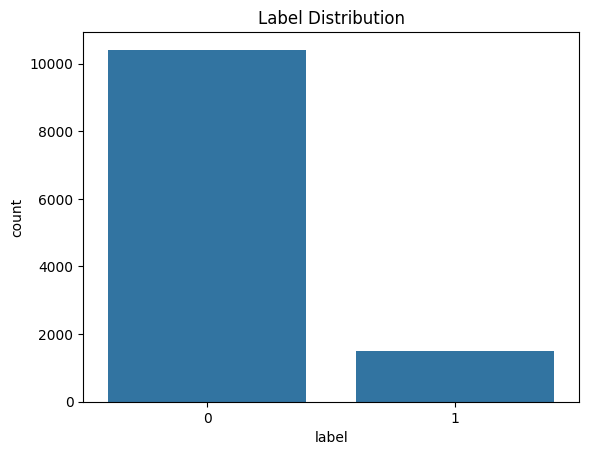

label
0    10411
1     1491
Name: count, dtype: int64

STEP 3: TEXT PREPROCESSING


Processing texts: 100%|██████████| 11902/11902 [00:01<00:00, 8193.90it/s]


Processed 11902 samples
Sample cleaned text: knocked doors with the venerable #teamtrudeau #lpc candidate  this aft in my hometown, aurora! #elxn42 :star-struck:
Sample hashtag text: team trudeau lpc elxn 42 

STEP 4: LOADING CLIP MODEL
Using device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Text embeddings shape: (11902, 512)

STEP 7: EXTRACTING HASHTAG EMBEDDINGS


Text embeddings: 100%|██████████| 372/372 [00:06<00:00, 59.72it/s]


Hashtag embeddings shape: (11902, 512)

STEP 8: EXTRACTING IMAGE EMBEDDINGS


Image embeddings: 100%|██████████| 372/372 [01:56<00:00,  3.19it/s]


Image embeddings shape: (11902, 512)

STEP 9: CREATING RELATIONAL FEATURES
Hashtag count shape: (11902,)
Hashtag freq shape: (11902,)

STEP 10: CREATING FINAL FEATURE MATRIX
Final feature shape: (11902, 3077)
Target shape: (11902,)

STEP 11: TRAIN-TEST SPLIT
Training set: (9521, 3077)
Test set: (2381, 3077)
Positive class weight: 6.98

STEP 12: TRAINING XGBOOST CLASSIFIER
⏱️ Training started at: 14:08:50
📊 Training on 9521 samples with 3077 features
⚙️ Parameters: n_estimators=400, max_depth=6, learning_rate=0.05

🔄 Training XGBoost with progress tracking...
⚠️ Callback method failed: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'
Falling back to standard training with simple progress...
[0]	validation_0-logloss:0.67485
[1]	validation_0-logloss:0.65748
[2]	validation_0-logloss:0.64328
[3]	validation_0-logloss:0.63028
[4]	validation_0-logloss:0.61832
[5]	validation_0-logloss:0.60589
[6]	validation_0-logloss:0.59504
[7]	validation_0-logloss:0.58504
[8]	validation_0-lo

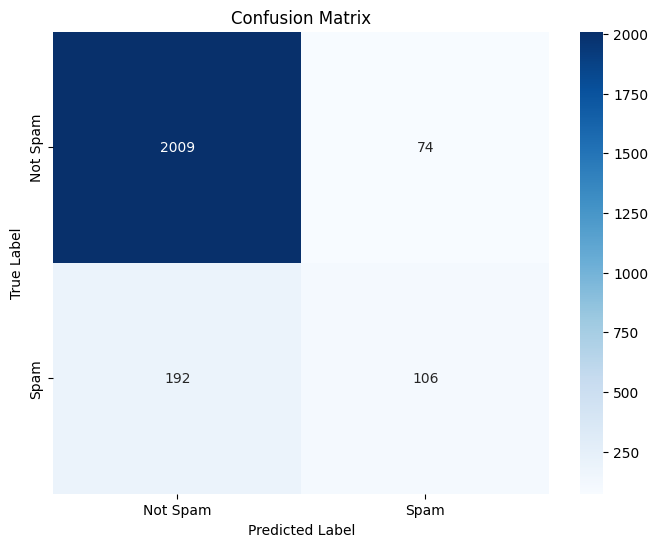


STEP 14: BASELINE COMPARISONS

TEXT MODEL
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      2083
           1       0.36      0.76      0.49       298

    accuracy                           0.80      2381
   macro avg       0.66      0.78      0.68      2381
weighted avg       0.88      0.80      0.83      2381

ROC-AUC: 0.8512285455605781

IMAGE MODEL
              precision    recall  f1-score   support

           0       0.94      0.75      0.84      2083
           1       0.28      0.65      0.39       298

    accuracy                           0.74      2381
   macro avg       0.61      0.70      0.61      2381
weighted avg       0.86      0.74      0.78      2381

ROC-AUC: 0.7782327051522875

TEXT + IMAGE MODEL
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2083
           1       0.54      0.35      0.42       298

    accuracy                           0.88      2

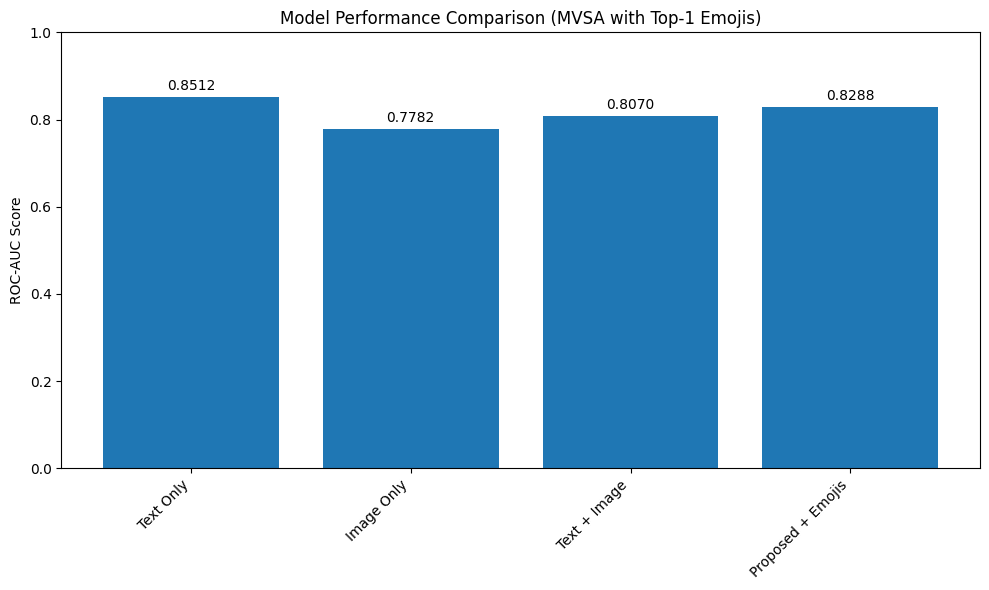


STEP 16: FEATURE IMPORTANCE ANALYSIS


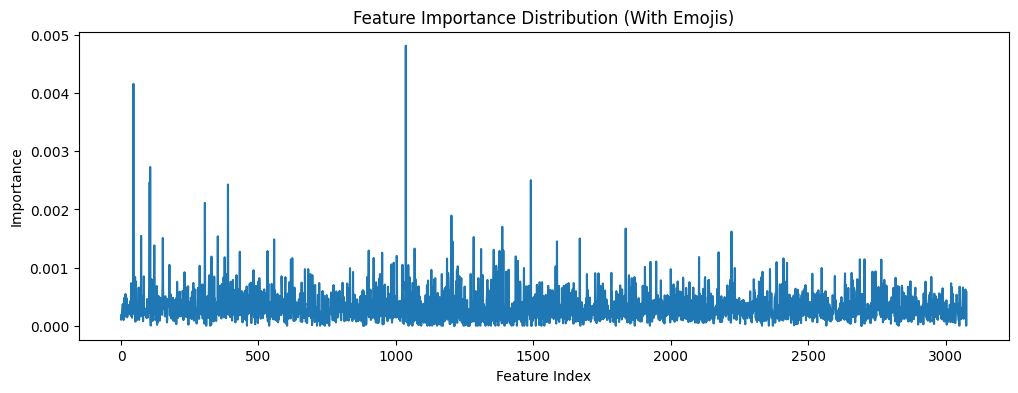

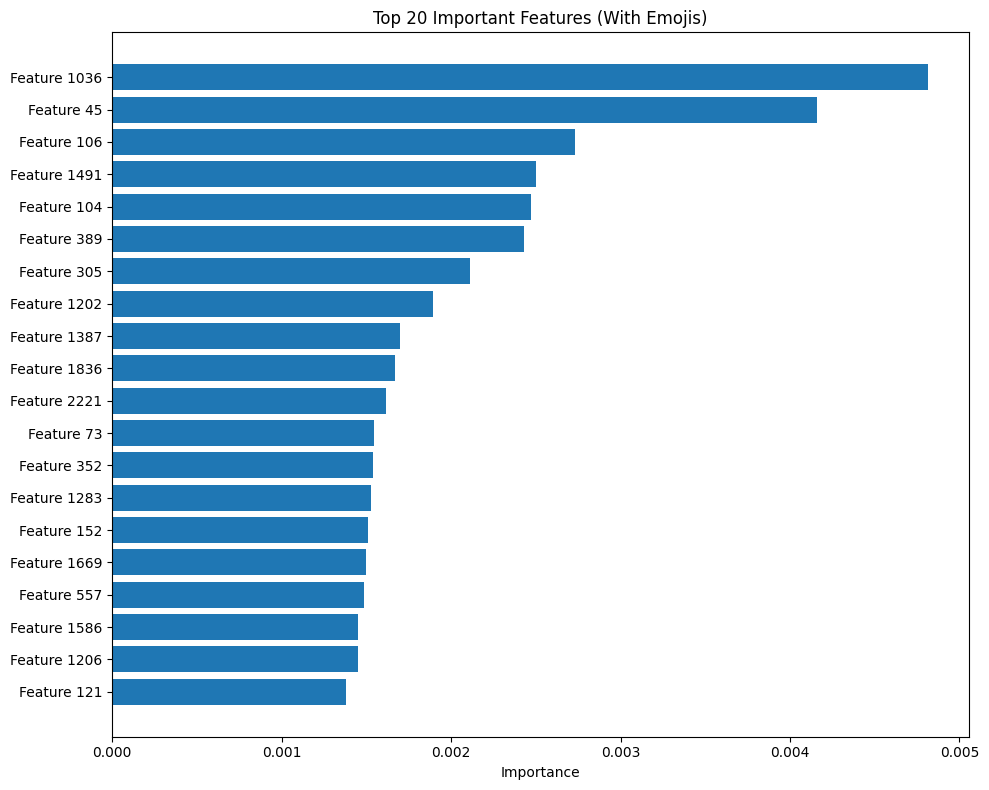


STEP 17: SAVING RESULTS
✅ Features and labels saved
✅ Model saved
✅ Predictions saved
✅ Results saved to /kaggle/working/

✅ PIPELINE COMPLETE - MVSA WITH TOP-1 EMOJIS PROCESSED

Results saved to /kaggle/working/
Files created:
  - X_features_with_emojis.npy
  - y_labels_with_emojis.npy
  - xgb_model_with_emojis.pkl
  - y_pred_with_emojis.npy
  - y_prob_with_emojis.npy
  - y_test_with_emojis.npy
  - model_comparison_with_emojis.csv


In [11]:
# ============================================
# COMPLETE PIPELINE FOR MVSA WITH TOP-1 PREDICTED EMOJIS
# Following exact same structure as original notebooks
# ============================================

# Cell 1: Install Dependencies
!pip install torch torchvision transformers scikit-learn pandas numpy tqdm emoji xgboost joblib

# Cell 2: Import Libraries
import os
import re
import emoji
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import CLIPProcessor, CLIPModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Cell 3: Load MVSA Dataset
print("="*60)
print("STEP 1: LOADING MVSA DATASET WITH TOP-1 PREDICTED EMOJIS")
print("="*60)

# CORRECT PATH - using your username
df = pd.read_csv("/kaggle/input/datasets/goyalsaloni/01-dataset-preparation/labeled.csv")
print(f"Original dataset size: {len(df)}")

# Check if we have the predicted emojis file
try:
    # Try to load existing predictions from working directory
    predictions_path = '/kaggle/working/mvsa_predictions_top1.csv'
    if os.path.exists(predictions_path):
        predictions_df = pd.read_csv(predictions_path)
        df['predicted_emoji'] = predictions_df['emoji_string']
        print("✅ Loaded existing top-1 emoji predictions from working directory")
    else:
        print("⚠️ No existing predictions found. Using original text without emojis.")
        df['predicted_emoji'] = ""
except Exception as e:
    print(f"⚠️ Could not load predictions: {e}")
    df['predicted_emoji'] = ""

# Convert all text to string to avoid float errors
df['text'] = df['text'].astype(str)
df['predicted_emoji'] = df['predicted_emoji'].astype(str)

# Create text with emoji for CLIP
df['text_with_emoji'] = df['text'] + " " + df['predicted_emoji']
df['text_for_clip'] = df['text_with_emoji'].apply(lambda x: emoji.demojize(str(x)))

print(f"\nDataset size: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df[['text', 'predicted_emoji', 'text_with_emoji']].head())

# Cell 4: Label Distribution
print("\n" + "="*60)
print("STEP 2: LABEL DISTRIBUTION")
print("="*60)

sns.countplot(x=df["label"])
plt.title("Label Distribution")
plt.show()

print(df["label"].value_counts())

# Cell 5: Text Preprocessing
print("\n" + "="*60)
print("STEP 3: TEXT PREPROCESSING")
print("="*60)

def clean_text(text):
    # Convert to string first
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = emoji.demojize(text)
    return text.lower().strip()

def extract_hashtags(text):
    # Convert to string first
    text = str(text)
    return re.findall(r"#\w+", text)

def segment_hashtag(tag):
    tag = tag.replace("#", "")
    tag = re.sub(r'([a-z])([A-Z])', r'\1 \2', tag)
    tag = re.sub(r'(\d+)', r' \1 ', tag)
    return tag.lower()

# Process text and hashtags
text_inputs = []
hashtag_inputs = []
image_paths = []
all_hashtags = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing texts"):
    clean = clean_text(row['text_with_emoji'])  # Use text with emoji
    hashtags = extract_hashtags(row['text'])
    segmented = [segment_hashtag(tag) for tag in hashtags]
    hashtag_text = " ".join(segmented) if segmented else "none"
    
    text_inputs.append(clean)
    hashtag_inputs.append(hashtag_text)
    image_paths.append(row["image_path"])
    all_hashtags.append(hashtags)

print(f"Processed {len(text_inputs)} samples")
print(f"Sample cleaned text: {text_inputs[0]}")
print(f"Sample hashtag text: {hashtag_inputs[0]}")

# Cell 6: Load CLIP Model
print("\n" + "="*60)
print("STEP 4: LOADING CLIP MODEL")
print("="*60)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("✅ CLIP model loaded")

# Cell 7: Define Embedding Functions (CORRECTED VERSION)
print("\n" + "="*60)
print("STEP 5: DEFINING EMBEDDING FUNCTIONS")
print("="*60)

def get_text_embeddings(text_list, batch_size=32):
    """Get CLIP text embeddings - CORRECTED VERSION"""
    embeddings = []
    for i in tqdm(range(0, len(text_list), batch_size), desc="Text embeddings"):
        batch = text_list[i:i+batch_size]
        inputs = processor(text=batch, padding=True, truncation=True, return_tensors="pt").to(device)
        
        with torch.no_grad():
            # Get text features through the text model
            text_outputs = clip_model.text_model(
                input_ids=inputs["input_ids"], 
                attention_mask=inputs["attention_mask"]
            )
            # Get the pooled output (CLS token)
            pooled_output = text_outputs.pooler_output
            # Apply text projection
            text_features = clip_model.text_projection(pooled_output)
            # Normalize features (optional but helps with similarity)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
        embeddings.append(text_features.cpu())
    
    # Concatenate all batches
    return torch.cat(embeddings, dim=0).numpy()

def get_image_embeddings(image_paths, batch_size=32):
    """Get CLIP image embeddings - CORRECTED VERSION"""
    embeddings = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Image embeddings"):
        batch_paths = image_paths[i:i+batch_size]
        images = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
            except Exception as e:
                # Use blank image if file not found or corrupted
                img = Image.new("RGB", (224, 224))
            images.append(img)
        
        inputs = processor(images=images, return_tensors="pt").to(device)
        
        with torch.no_grad():
            # Get image features through the vision model
            vision_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
            # Get the pooled output
            pooled_output = vision_outputs.pooler_output
            # Apply visual projection
            image_features = clip_model.visual_projection(pooled_output)
            # Normalize features
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            
        embeddings.append(image_features.cpu())
    
    # Concatenate all batches
    return torch.cat(embeddings, dim=0).numpy()

print("✅ Embedding functions defined")

# Cell 8: Extract Text Embeddings
print("\n" + "="*60)
print("STEP 6: EXTRACTING TEXT EMBEDDINGS")
print("="*60)

text_emb = get_text_embeddings(text_inputs)
print(f"Text embeddings shape: {text_emb.shape}")

# Cell 9: Extract Hashtag Embeddings
print("\n" + "="*60)
print("STEP 7: EXTRACTING HASHTAG EMBEDDINGS")
print("="*60)

hash_emb = get_text_embeddings(hashtag_inputs)
print(f"Hashtag embeddings shape: {hash_emb.shape}")

# Cell 10: Extract Image Embeddings
print("\n" + "="*60)
print("STEP 8: EXTRACTING IMAGE EMBEDDINGS")
print("="*60)

img_emb = get_image_embeddings(image_paths)
print(f"Image embeddings shape: {img_emb.shape}")

# Cell 11: Create Relational Features
print("\n" + "="*60)
print("STEP 9: CREATING RELATIONAL FEATURES")
print("="*60)

flat_tags = [tag for tags in all_hashtags for tag in tags]
freq_dict = Counter(flat_tags)

hashtag_count = np.array([len(tags) for tags in all_hashtags])
hashtag_freq = np.array([sum(freq_dict[t] for t in tags) if tags else 0 for tags in all_hashtags])

print(f"Hashtag count shape: {hashtag_count.shape}")
print(f"Hashtag freq shape: {hashtag_freq.shape}")

# Cell 12: Create Final Feature Matrix (Exactly like 05-proposed-model.ipynb)
print("\n" + "="*60)
print("STEP 10: CREATING FINAL FEATURE MATRIX")
print("="*60)

def normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-8)

text_n = normalize(text_emb)
img_n = normalize(img_emb)
hash_n = normalize(hash_emb)

# Calculate similarities
text_img_sim = np.sum(text_n * img_n, axis=1)
text_hash_sim = np.sum(text_n * hash_n, axis=1)
img_hash_sim = np.sum(img_n * hash_n, axis=1)

# Calculate absolute differences
text_img_diff = np.abs(text_emb - img_emb)
text_hash_diff = np.abs(text_emb - hash_emb)
img_hash_diff = np.abs(img_emb - hash_emb)

# Reshape for concatenation
text_img_sim = text_img_sim.reshape(-1,1)
text_hash_sim = text_hash_sim.reshape(-1,1)
img_hash_sim = img_hash_sim.reshape(-1,1)
hashtag_count = hashtag_count.reshape(-1,1)
hashtag_freq = hashtag_freq.reshape(-1,1)

# Concatenate all features (exactly as in 05-proposed-model.ipynb)
X = np.concatenate([
    text_emb,
    img_emb,
    hash_emb,
    text_img_diff,
    text_hash_diff,
    img_hash_diff,
    text_img_sim,
    text_hash_sim,
    img_hash_sim,
    hashtag_count,
    hashtag_freq
], axis=1)

y = df["label"].values

print(f"Final feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Cell 13: Train-Test Split (Exactly like 05-proposed-model.ipynb)
print("\n" + "="*60)
print("STEP 11: TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
pos_weight = neg / pos

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Positive class weight: {pos_weight:.2f}")

# Cell 14: Train XGBoost with Progress Tracking
print("\n" + "="*60)
print("STEP 12: TRAINING XGBOOST CLASSIFIER")
print("="*60)

# Add time tracking
import time
from datetime import datetime, timedelta

start_time = time.time()
print(f"⏱️ Training started at: {datetime.now().strftime('%H:%M:%S')}")
print(f"📊 Training on {X_train.shape[0]} samples with {X_train.shape[1]} features")
print(f"⚙️ Parameters: n_estimators=400, max_depth=6, learning_rate=0.05")
print()

# Create progress callback
class ProgressCallback:
    def __init__(self, rounds=400):
        self.rounds = rounds
        self.start_time = time.time()
        
    def __call__(self, after_iteration):
        # This is called after each boosting round
        import sys
        
        # Get current iteration (XGBoost internal counter)
        current = after_iteration.iteration + 1
        
        # Calculate progress
        progress = current / self.rounds
        bar_length = 40
        filled = int(bar_length * progress)
        bar = '█' * filled + '░' * (bar_length - filled)
        
        # Calculate time
        elapsed = time.time() - self.start_time
        if current > 0:
            estimated_total = elapsed / progress
            remaining = estimated_total - elapsed
            eta_str = str(timedelta(seconds=int(remaining)))
        else:
            eta_str = "calculating..."
        
        # Print progress bar (overwrite same line)
        sys.stdout.write(f'\r🔄 Progress: |{bar}| {progress*100:.1f}% '
                        f'[{current}/{self.rounds}] '
                        f'⏱️ Elapsed: {str(timedelta(seconds=int(elapsed)))} '
                        f'⏳ ETA: {eta_str}')
        sys.stdout.flush()
        
        # Return False to continue training
        return False

# Option 1: With custom callback (for detailed progress)
try:
    print("🔄 Training XGBoost with progress tracking...")
    
    xgb_model = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        tree_method="hist",  # or "gpu_hist" if you have GPU
        n_jobs=-1,
        random_state=42,
        verbosity=0  # Reduce XGBoost's own output
    )
    
    # Fit with custom callback
    xgb_model.fit(
        X_train, y_train,
        callbacks=[ProgressCallback(rounds=400)]
    )
    
    print("\n")  # New line after progress bar
    
except Exception as e:
    print(f"⚠️ Callback method failed: {e}")
    print("Falling back to standard training with simple progress...")
    
    # Option 2: Simple alternative with periodic prints
    xgb_model = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        verbosity=1  # XGBoost's built-in progress
    )
    
    # Fit with evaluation set to see progress
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=True
    )

# Calculate total time
end_time = time.time()
total_time = end_time - start_time
print(f"✅ Model training complete in {str(timedelta(seconds=int(total_time)))}")
print(f"⏱️ Finished at: {datetime.now().strftime('%H:%M:%S')}")

# Cell 15: Evaluate Model (Exactly like 05-proposed-model.ipynb)
print("\n" + "="*60)
print("STEP 13: MODEL EVALUATION")
print("="*60)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['Not Spam (0)', 'Spam (1)']))
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Cell 16: Baseline Comparisons
print("\n" + "="*60)
print("STEP 14: BASELINE COMPARISONS")
print("="*60)

# Get same indices for fair comparison
X_train_idx, X_test_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 1. TEXT MODEL
print("\n" + "="*40)
print("TEXT MODEL")
print("="*40)
X_text_train = text_emb[X_train_idx]
X_text_test = text_emb[X_test_idx]
y_train_text = y[X_train_idx]
y_test_text = y[X_test_idx]

clf_text = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_text.fit(X_text_train, y_train_text)
pred_text = clf_text.predict(X_text_test)
prob_text = clf_text.predict_proba(X_text_test)[:,1]
print(classification_report(y_test_text, pred_text))
print("ROC-AUC:", roc_auc_score(y_test_text, prob_text))

# 2. IMAGE MODEL
print("\n" + "="*40)
print("IMAGE MODEL")
print("="*40)
X_img_train = img_emb[X_train_idx]
X_img_test = img_emb[X_test_idx]

clf_img = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_img.fit(X_img_train, y_train_text)
pred_img = clf_img.predict(X_img_test)
prob_img = clf_img.predict_proba(X_img_test)[:,1]
print(classification_report(y_test_text, pred_img))
print("ROC-AUC:", roc_auc_score(y_test_text, prob_img))

# 3. TEXT + IMAGE
print("\n" + "="*40)
print("TEXT + IMAGE MODEL")
print("="*40)
X_ti = np.concatenate([text_emb, img_emb], axis=1)
X_ti_train = X_ti[X_train_idx]
X_ti_test = X_ti[X_test_idx]

clf_ti = XGBClassifier(eval_metric="logloss", tree_method="hist", 
                       scale_pos_weight=pos_weight, random_state=42)
clf_ti.fit(X_ti_train, y_train_text)
pred_ti = clf_ti.predict(X_ti_test)
prob_ti = clf_ti.predict_proba(X_ti_test)[:,1]
print(classification_report(y_test_text, pred_ti))
print("ROC-AUC:", roc_auc_score(y_test_text, prob_ti))

# 4. PROPOSED MODEL (with emojis) - already computed
print("\n" + "="*40)
print("PROPOSED MODEL (WITH EMOJIS)")
print("="*40)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc)

# Cell 17: Comparison Results
print("\n" + "="*60)
print("STEP 15: MODEL COMPARISON SUMMARY")
print("="*60)

results = pd.DataFrame({
    "Model": [
        "Text Only",
        "Image Only",
        "Text + Image",
        "Proposed + Emojis"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_text, prob_text),
        roc_auc_score(y_test_text, prob_img),
        roc_auc_score(y_test_text, prob_ti),
        roc_auc
    ]
})

print(results.to_string(index=False))

# Plot comparison
plt.figure(figsize=(10,6))
bars = plt.bar(results['Model'], results['ROC-AUC'])
plt.ylabel('ROC-AUC Score')
plt.title('Model Performance Comparison (MVSA with Top-1 Emojis)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

for bar, score in zip(bars, results['ROC-AUC']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Cell 18: Feature Importance
print("\n" + "="*60)
print("STEP 16: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

importances = xgb_model.feature_importances_

plt.figure(figsize=(12,4))
plt.plot(importances)
plt.title("Feature Importance Distribution (With Emojis)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# Top 20 features
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(10,8))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), [f"Feature {i}" for i in top_idx])
plt.title("Top 20 Important Features (With Emojis)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Cell 19: Save Everything
print("\n" + "="*60)
print("STEP 17: SAVING RESULTS")
print("="*60)

# Save features and labels
np.save("/kaggle/working/X_features_with_emojis.npy", X)
np.save("/kaggle/working/y_labels_with_emojis.npy", y)
print("✅ Features and labels saved")

# Save model
joblib.dump(xgb_model, "/kaggle/working/xgb_model_with_emojis.pkl")
print("✅ Model saved")

# Save predictions
np.save("/kaggle/working/y_pred_with_emojis.npy", y_pred)
np.save("/kaggle/working/y_prob_with_emojis.npy", y_prob)
np.save("/kaggle/working/y_test_with_emojis.npy", y_test)
print("✅ Predictions saved")

# Save comparison results
results.to_csv("/kaggle/working/model_comparison_with_emojis.csv", index=False)
print("✅ Results saved to /kaggle/working/")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETE - MVSA WITH TOP-1 EMOJIS PROCESSED")
print("="*60)
print("\nResults saved to /kaggle/working/")
print("Files created:")
print("  - X_features_with_emojis.npy")
print("  - y_labels_with_emojis.npy")
print("  - xgb_model_with_emojis.pkl")
print("  - y_pred_with_emojis.npy")
print("  - y_prob_with_emojis.npy")
print("  - y_test_with_emojis.npy")
print("  - model_comparison_with_emojis.csv")